#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час

<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Описание-проекта" data-toc-modified-id="Описание-проекта-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Описание проекта</a></span></li><li><span><a href="#Импорт-данных-и-разведочный-анализ" data-toc-modified-id="Импорт-данных-и-разведочный-анализ-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Импорт данных и разведочный анализ</a></span><ul class="toc-item"><li><span><a href="#Вывод" data-toc-modified-id="Вывод-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Исследовательский-анализ" data-toc-modified-id="Исследовательский-анализ-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Исследовательский анализ</a></span><ul class="toc-item"><li><span><a href="#Стационарность-ряда" data-toc-modified-id="Стационарность-ряда-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Стационарность ряда</a></span></li><li><span><a href="#Декомпозиция-ряда-на-тренд-и-сезонность" data-toc-modified-id="Декомпозиция-ряда-на-тренд-и-сезонность-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Декомпозиция ряда на тренд и сезонность</a></span></li><li><span><a href="#Автокорреляция" data-toc-modified-id="Автокорреляция-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Автокорреляция</a></span></li><li><span><a href="#Создание-дополнительных-признаков" data-toc-modified-id="Создание-дополнительных-признаков-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Создание дополнительных признаков</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-3.5"><span class="toc-item-num">3.5&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Подбор-и-обучение-модели" data-toc-modified-id="Подбор-и-обучение-модели-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Подбор и обучение модели</a></span><ul class="toc-item"><li><span><a href="#Ridge" data-toc-modified-id="Ridge-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Ridge</a></span></li><li><span><a href="#Random-Forest" data-toc-modified-id="Random-Forest-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Random Forest</a></span></li><li><span><a href="#LGBM" data-toc-modified-id="LGBM-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>LGBM</a></span></li><li><span><a href="#Prophet" data-toc-modified-id="Prophet-4.4"><span class="toc-item-num">4.4&nbsp;&nbsp;</span>Prophet</a></span></li><li><span><a href="#Сравнение-моделей" data-toc-modified-id="Сравнение-моделей-4.5"><span class="toc-item-num">4.5&nbsp;&nbsp;</span>Сравнение моделей</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-4.6"><span class="toc-item-num">4.6&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Анализ-лучшей-модели" data-toc-modified-id="Анализ-лучшей-модели-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Анализ лучшей модели</a></span></li><li><span><a href="#Общий-вывод" data-toc-modified-id="Общий-вывод-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Общий вывод</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

## Описание проекта

**Заказчик**


Компания по оказанию услуг такси


**Входные данные**


Исторические данные о заказах такси в аэропортах, время и количество


**Задача**


Проанализировать данные и обучить предсказательные модели количества заказов такси на следующий час с разными гиперпараметрами. Оценка модели должна проводиться на тестовой выборке по метрике RMSE, должно быть не больше 48


**Цель**


Привлекать больше водителей в период пиковой нагрузки с использованием предсказательной модели

**Описание входных данных**

`/datasets/taxi.csv` - таблица с датой и временем поездок, а также их количеством

- `datetime` - дата и время поездок
- `num_orders` - количество поездок в указанный промежуток времени

In [1]:
!pip install scikit-learn --upgrade -q
!pip install hyperopt -q
!pip install prophet -q
!pip install lightgbm -q

In [2]:
# данные
import pandas as pd
import numpy as np
import datetime
import random
import warnings
import time
from functools import partial
import logging
from copy import deepcopy

# графики
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# статистика
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics import tsaplots
from statsmodels.tsa.statespace.sarimax import SARIMAX

# мо
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_val_predict,
    RandomizedSearchCV,
    TimeSeriesSplit
)
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer, make_column_selector

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from prophet import Prophet
from lightgbm import LGBMRegressor

from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics
from prophet import Prophet

RANDOM_STATE=42
random.seed(42)
np.random.seed(42)
pd.set_option('display.max_columns', None)
warnings.filterwarnings("ignore")

## Импорт данных и разведочный анализ

In [3]:
df = pd.read_csv('/datasets/taxi.csv', 
                 index_col=['datetime'], 
                 parse_dates=['datetime'])
df.sort_index(inplace=True)
print('Сводная информация по изначальным данным \n')
df.info()
print('\n Первые записи таблицы')
display(df.head(7))
print('\n Статистика по числовым столбцам')
display(df.describe())

Сводная информация по изначальным данным 

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB

 Первые записи таблицы


,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32
2018-03-01 00:50:00,21
2018-03-01 01:00:00,7



 Статистика по числовым столбцам


,num_orders
count,26496.000000
mean,14.070463
std,9.211330
min,0.000000
25%,8.000000
50%,13.000000
75%,19.000000
max,119.000000


- Изначально в данных содержится 26496 записей
- Период с 1 марта 2018 по 31 августа 2018 года
- Интервал 10 минут
- Пропусков нет
- Явных аномалий нет, вроде отрицательного количества поездок, но есть периоды без поездок, что скорее всего нормально

Проверим нет ли у нас пропущенных периодов

In [4]:
(df.index.max() - df.index.min()) / np.timedelta64(10, 'm')

26495.0

Все в порядке, на каждые 10 минут есть запись (на 1 меньше, так как не включилась первая запись). Сделаем ресемпл по 1 часу

In [5]:
df = df.resample('1H').sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB


In [6]:
6*4416

26496

Отлично, все записи ресемплировались без "неполных" часов в начале или конце

### Вывод

- Изначальные данные
    - 26496 записей
    - Период с 1 марта 2018 по 31 августа 2018 года, будут проблемы сезонного влияния, так как охвачен не весь год, зимой, например на праздники так же может быть рост поездок
    - Интервал 10 минут
    - Пропусков нет
    - Явных аномалий нет, вроде отрицательного количества поездок, но есть периоды без поездок, что скорее всего нормально
    
- Ресемплировали по 1 часу, стало 4416 записей

## Исследовательский анализ

###  Стационарность ряда

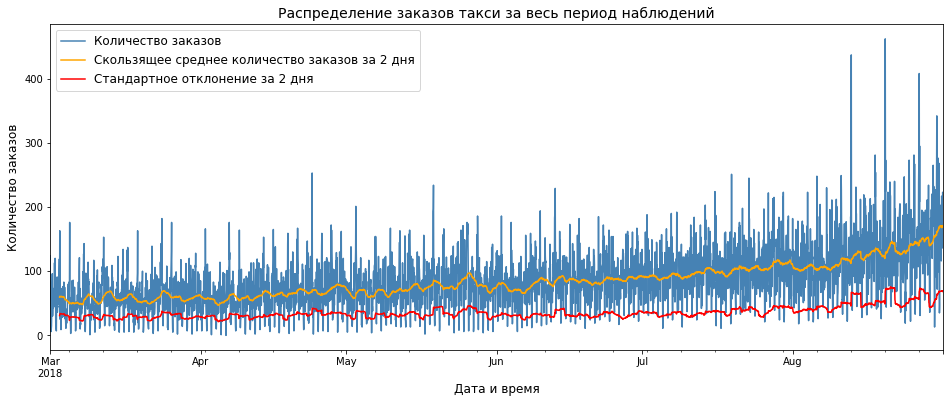

In [7]:
FIGSIZE = (16, 6)
df_ = df.copy()
df_['mean'] = df['num_orders'].rolling(48).mean()
df_['std'] = df['num_orders'].rolling(48).std()
df_.plot(figsize=FIGSIZE, color=['steelblue', 'orange', 'red'])
plt.title('Распределение заказов такси за весь период наблюдений', fontsize=14)
plt.xlabel('Дата и время', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
plt.legend(['Количество заказов', 
            'Скользящее среднее количество заказов за 2 дня', 
            'Стандартное отклонение за 2 дня'], fontsize=12);

С одной стороны наблюдается квазистационарность процесса, хотя с другой стороны это проблема масштаба, потомучто наблюдается небольшой рост тренда к концу лета. Применим статистический тест Дики — Фуллера, чтобы подкрепить или опровергнуть нашу оценку

- Нулевая гипотеза
    - Временной ряд нестационарен
- Альтернативная гипотеза
    - Временной ряд стационарен

In [8]:
ad_test = adfuller(df)
print('adf: ', ad_test[0])
print('p-value:', ad_test[1])
print('Critical values:', ad_test[4])
if ad_test[0] > ad_test[4] ['5%']:
    print('Есть единичные корни, ряд нестационарен')
else:
    print('Единичных корней нет, ряд стационарен')

adf:  -3.0689242890279558
p-value: 0.028940051402612906
Critical values: {'1%': -3.431842162413052, '5%': -2.8621993540813637, '10%': -2.567120978470452}
Единичных корней нет, ряд стационарен


Получается, что ряд все же стационарен (p = 0.029), отлично, значит в некотором смысле модели будет проще делать предсказание

Посмотрим на ряд со сдвигом в 1 час

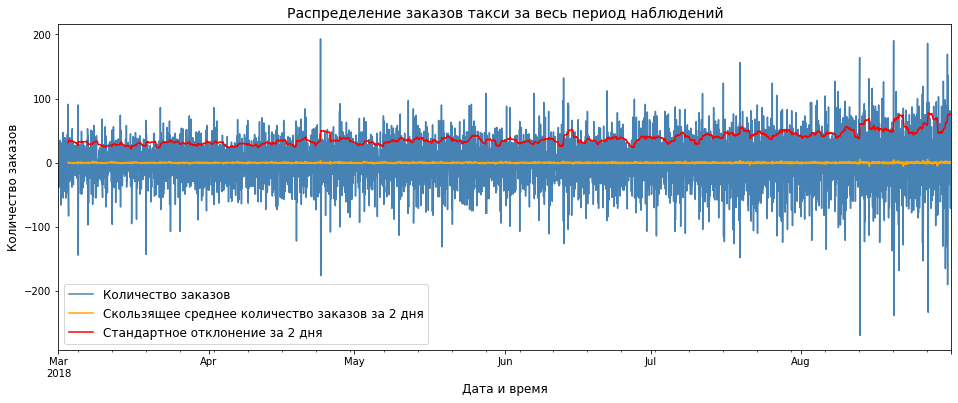

In [9]:
FIGSIZE = (16, 6)
df_shifted = df - df.shift()
df_shifted['mean'] = df_shifted['num_orders'].rolling(48).mean()
df_shifted['std'] = df_shifted['num_orders'].rolling(48).std()
df_shifted.plot(figsize=FIGSIZE, color=['steelblue', 'orange', 'red'])
plt.title('Распределение заказов такси за весь период наблюдений', fontsize=14)
plt.xlabel('Дата и время', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
plt.legend(['Количество заказов', 
            'Скользящее среднее количество заказов за 2 дня', 
            'Стандартное отклонение за 2 дня'], fontsize=12);

Ряд выглядит достаточно стационарным, средняя около 0, стандартное отклонение слегка растет к августу

### Декомпозиция ряда на тренд и сезонность

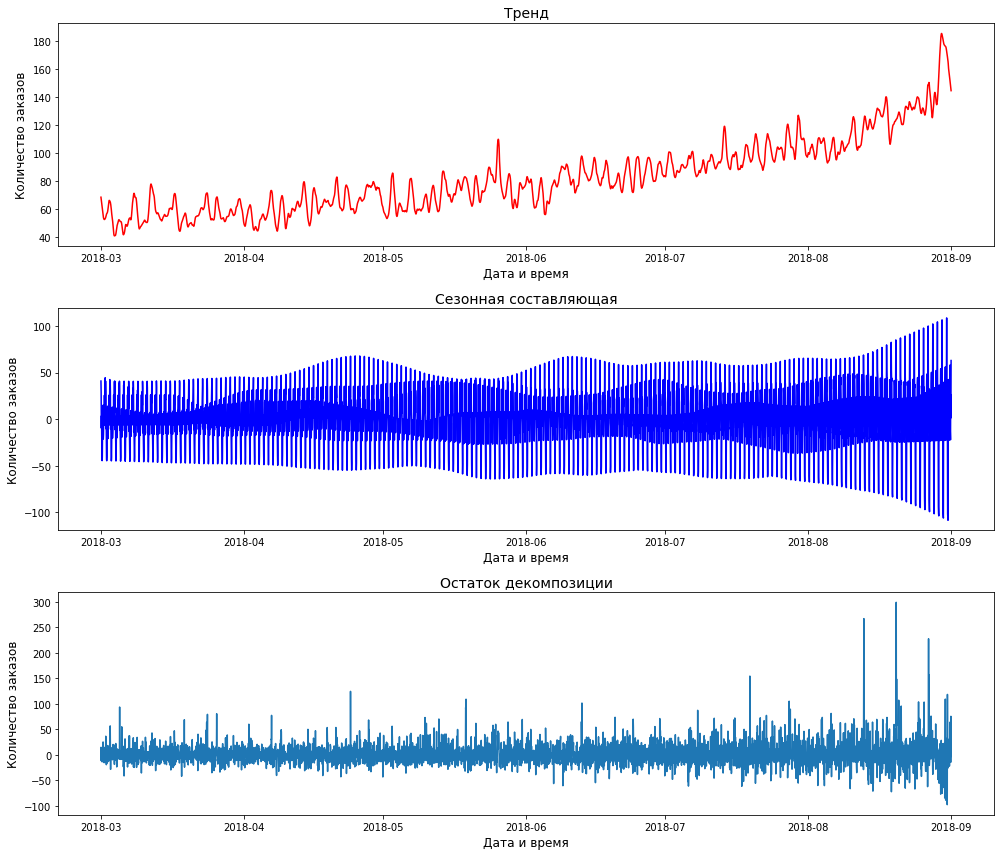

In [10]:
stl = STL(df['num_orders'], seasonal=25, trend=25, robust=True) 
result = stl.fit()

fig, ax = plt.subplots(3, 1, figsize=(14, 12))
ax[0].plot(df.index, result.trend, color='red')
ax[0].set_title('Тренд', fontsize=14)
ax[1].plot(df.index, result.seasonal, color='blue')
ax[1].set_title('Сезонная составляющая', fontsize=14)
ax[2].plot(df.index, result.resid)
ax[2].set_title('Остаток декомпозиции', fontsize=14)
for ax in ax:
    ax.set_xlabel('Дата и время', fontsize=12)
    ax.set_ylabel('Количество заказов', fontsize=12)
plt.tight_layout()

- Тренд расетет к концу августа, что по идее может быть связано с увеличением количества отпусков и возвращения из них, дальше по идее должно быть снижение до декабря-начала января с последующим падением до мартовских значений, но точно нам этого не известно
- Сезонная составляющая, в нашем случае - 1 день показывет явную периодичность, кроме того можно заметить изменение амплитуды колебаний, а именно увеличение в мае с небольшим снижением и последующий рост амплитуды в августе
- По остаткам видны выбросы в некоторые моменты периода, возможно это выходные в августе, когда отпусков больше всего, кроме того это могут быть праздничные дни
- Изучим графики более детально

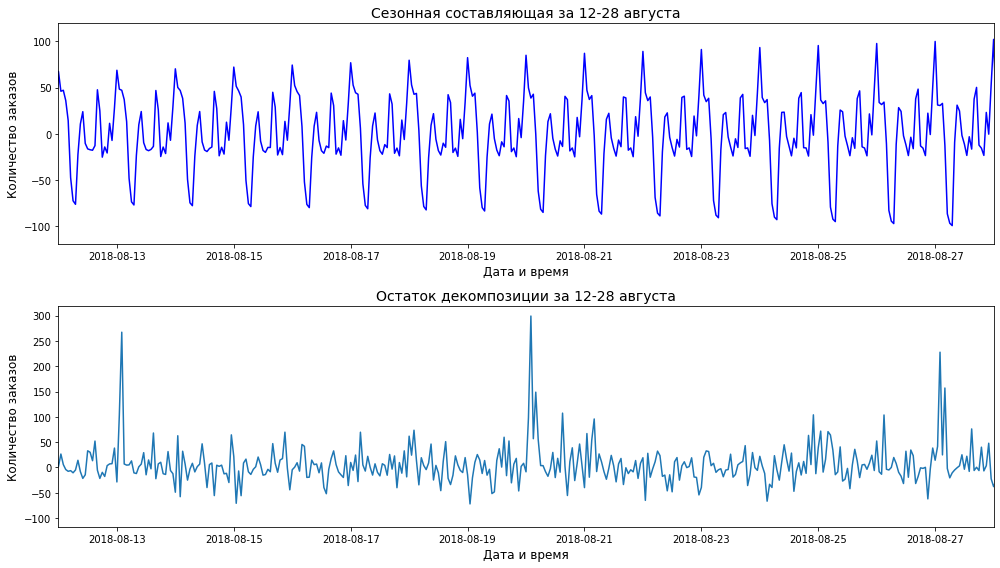

In [11]:
fig, ax = plt.subplots(2, 1, figsize=(14, 8))

ax[0].plot(df.index, result.seasonal, color='blue')
ax[0].set_title('Сезонная составляющая за 12-28 августа', fontsize=14)
ax[1].plot(df.index, result.resid)
ax[1].set_title('Остаток декомпозиции за 12-28 августа', fontsize=14)

for ax in ax:
    ax.set_xlabel('Дата и время', fontsize=12)
    ax.set_ylabel('Количество заказов', fontsize=12)
    ax.set_xlim([datetime.date(2018, 8, 12), datetime.date(2018, 8, 28)])

plt.tight_layout()

- Всплески в остатке от декомпозиции приходятся на 13, 20 и 27 августа 2018 года на выделенном участке. Если открыть календарь, то эти даты - понедельники
- Можно предположить, что это как раз прилеты из отпусков в аэропорт и следовательно резкий рост заказов
- Также, возможно, может быть влияние начала учебного года и осени, люди идут в университет или устраиваются на работу чаще в конце лета
- Так как данных за прошлый год у нас нет, а требование заказчика - 10% в тестовой выборке (получается около 440 записей или 18 последних дней), то обучение модели на таких данных может стать проблемой, так как последняя часть выборки попадет в тестовую часть, будем внимательнее с кроссвалидацией, может там получиться решить проблему
- В сезонной составляющей наблюдается внутридневной периодический паттерн, при этом выходные никак не выделяются

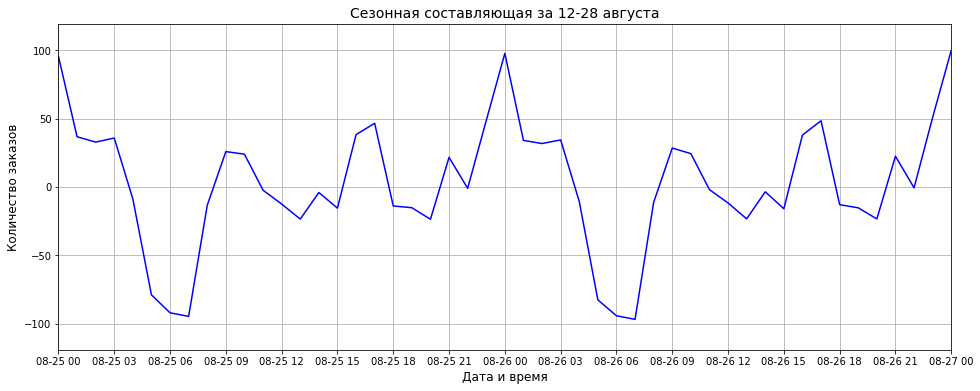

In [12]:
plt.figure(figsize=(16, 6))
plt.plot(df.index, result.seasonal, color='blue')
plt.title('Сезонная составляющая за 12-28 августа', fontsize=14)
plt.xlabel('Дата и время', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.HourLocator(interval=3))
plt.xlim([datetime.date(2018, 8, 25), datetime.date(2018, 8, 27)])
plt.grid();

- Пик заказов приходится на ночное время, а именно около полуночи, чаще возвращаются ночные рейсы, а вылеты получается, что днем
- Минимум заказов в районе 6 утра и к 9 утра выходит на среднее значение
- Так же есть небольшой пик в районе 16 часов и небольшая просадка около 19 часов
- То есть, в целом, наиболее вероятно надо будет увеличивать число машин на подачу в указанные пиковые часы

### Автокорреляция

Посмотрим на автокорреляцию количества заказов в зависимости от временного лага

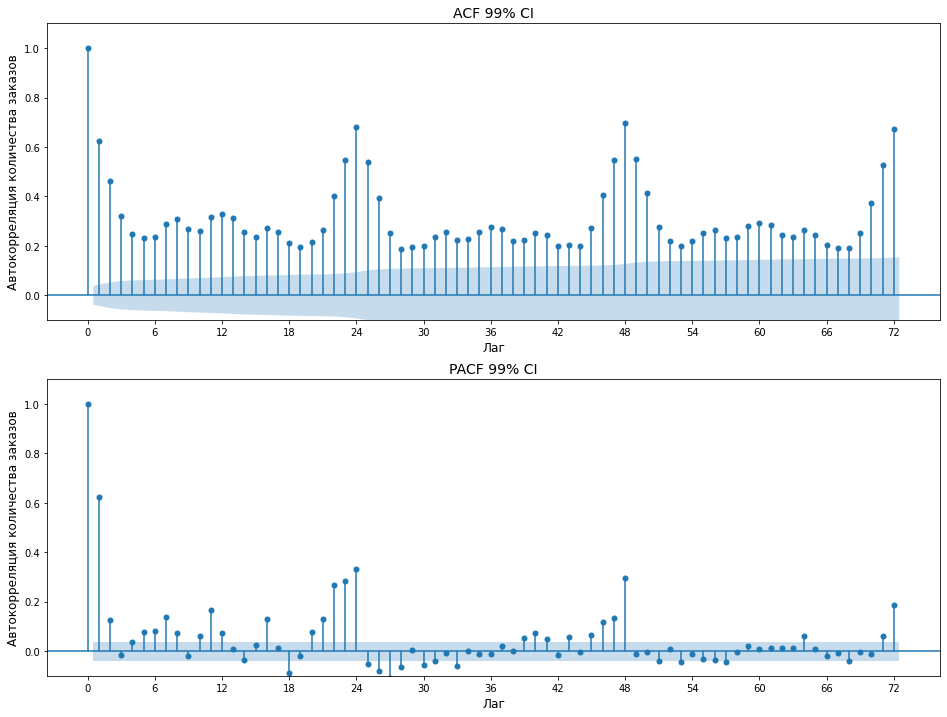

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(16, 12))
tsaplots.plot_acf(df['num_orders'], lags=72, alpha=0.01, ax=ax[0])
ax[0].set_title('ACF 99% CI', fontsize=14)
ax[0].set_xlabel('Лаг', fontsize=12)
ax[0].set_ylabel('Автокорреляция количества заказов', fontsize=12)
ax[0].set_ylim(-0.1, 1.1)
ax[0].set_xticks(range(0, 73, 6))

tsaplots.plot_pacf(df['num_orders'], lags=72, alpha=0.01, ax=ax[1])
ax[1].set_title('PACF 99% CI', fontsize=14)
ax[1].set_xlabel('Лаг', fontsize=12)
ax[1].set_ylabel('Автокорреляция количества заказов', fontsize=12)
ax[1].set_ylim(-0.1, 1.1)
ax[1].set_xticks(range(0, 73, 6));

- Видим локальный максимум через 24 часа с r24 около 0.70, что означает довольно значимую положительную суточную автокорреляцию
- Так же хорошую автокорреляцию показывает значение через 1 и 2 часа на уровне около 0.60 и 0.45
- Остальные соседние лаги показывают слабую автокорреляцию около 0.30-0.25
- Для дополнительных признаков выберем лаги до 24 часов или кратные число
- Сдвиги без промежуточных взаимосвязей показывают сильную корреляцию с сдигами
    - 1 - около 0.61
    - 22-24 - около 0.3
    - 48 и далеее кратные 24 - около 0.3

### Создание дополнительных признаков

Зададим функцию для создания дополнительных признаков дней, часов и 1 сдвига, остальные сдвиги уберем в пайплайн

In [14]:
def make_features(df):
    data = df.copy()
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    data['hour'] = data.index.hour
  
    return data

In [15]:
df = make_features(df)

### Вывод

- Ряд стационарен (**p**=0.029)
- Тренд постепенно возрастает к концу периода наблюдений, к августу
- Сезонность - 1 день
- По остаткам есть выбросы в конце наблюдений, в августе, что связано с возвращаением отпусков
- Автокорреляция 
    - Локальные максимумы кратны 24 часам с r около 0.30
    - Так же хорошую автокорреляцию показывает значение через 1 и 2 часа на уровне около 0.60 и 0.45
    - Сдвиги без промежуточных взаимосвязей показывают сильную корреляцию с сдвигами
        1 - около 0.61
        22-24 - около 0.3
        48 и далеее кратные 24 - около 0.3
- Будем добавлять сдвиги на основе автокорреляции, т.е. кратные 24 часам, а также в пределах первого дня

## Подбор и обучение модели

Будем выбирать из следующих моделей

- Ridge
- Random Forest
- LGBM
- Prophet


В качестве метрики для кросс-валидации будем использовать по требованию заказчика RMSE. Для кросс-валидации будем использовать будем использовать TimeSeriesSplit с n=5. Для оптимизации подбора гиперпараметров будем использовать HyperOpt

In [16]:
train, test = train_test_split(df,
                               test_size=0.1,
                               shuffle=False)

Создадим класс для пайплайна, где можно будет перебирать размеры сдвига и скользящего среднего в оптимизаторе

In [17]:
from sklearn.base import BaseEstimator, TransformerMixin

class LagAndRolling(BaseEstimator, TransformerMixin):

    '''
    Класс добавляет дополнительные признаки сдвигов и скользящего среднего. 
    Добавляет сдвиги кратные 24 часам, а так же сдвиги внутри 24 часов. Добавляет скользящее среднее
    
    Принимает на вход датасет, у которого index размерности datetime и есть таргет в качестве признака.
    
    max_lag - определяет максимальныц сдвиг кратный 24 
    rolling_mean_size - размер скользящего среднего
    max_lag_intraday - максимальный сдвиг внутри 24 часов
    target - целевая переменная
    
    Возвращает выборку с новыми признаками без таргета
    '''
    
    def __init__(self, max_lag=24, rolling_mean_size=24, max_lag_intraday=23, target=None):
        
        self.max_lag = max_lag
        self.rolling_mean_size = rolling_mean_size
        self.max_lag_intraday = max_lag_intraday
        self.target = target
        
    def fit(self, X, y=None):
        
        self.y_ = X[self.target] # целевая переменная тренировочной выборки
        self.fit_flag = 0 # флаг обучения, равен 0 если обучения не было, 1 - если преобразователь уже обучен
        
        return self

    def transform(self, X, y=None):
        self.X_ = X.copy()
        cols_num = self.X_.shape[1]
        self.X_['rolling_mean'] = self.X_[self.target].shift().rolling(self.rolling_mean_size).mean()
        
        # создание сдвигов и заполнение пропусков во время обучения
        if self.fit_flag == 0:
            self.X_.iloc[:self.rolling_mean_size, cols_num] = self.y_[:self.rolling_mean_size].mean()
            
            # сдвиги кратные дню
            for lag in range(24, self.max_lag+1, 24):
                self.X_[f'lag_{lag}'] = self.X_[self.target].shift(lag)
                
                # заполняем пропуски из следующего дня относительно сдвига тренировочной выборки
                self.X_.iloc[:lag, cols_num+lag//24] = self.y_[24:24+lag].values.T

            for lag in range(1, self.max_lag_intraday+1):
                self.X_[f'lag_{lag}'] = self.X_[self.target].shift(lag)
                self.X_.iloc[:lag, cols_num+lag+self.max_lag//24] = self.y_[24:24+lag].values.T 
        
        # создание сдвигов и заполнение пропусков, если оптимизатор уже обучен
        else:        
            self.X_.iloc[:self.rolling_mean_size, cols_num] = self.y_[-self.rolling_mean_size:].mean()

            for lag in range(24, self.max_lag+1, 24):
                self.X_[f'lag_{lag}'] = self.X_[self.target].shift(lag)
                
                # заполняем пропуски из конца тренировочной выборки
                self.X_.iloc[:lag, cols_num+lag//24] = self.y_[-lag:].values.T

            for lag in range(1, self.max_lag_intraday+1):
                self.X_[f'lag_{lag}'] = self.X_[self.target].shift(lag)
                self.X_.iloc[:lag, cols_num+lag+self.max_lag//24] = self.y_[-lag:].values.T            
        
        # выбрасываем таргет из обучающей выборки и ставим флаг обучения в 1
        self.X_ = self.X_.drop(columns=self.target, axis=1)
        self.fit_flag = 1
        
        return self.X_

Добавим пайплайн и определим вспомогательные функции

In [18]:
preprocessor = ColumnTransformer(
    [
        ('num', 'passthrough', make_column_selector(dtype_include=np.number))
    ])

pipe_search = Pipeline(
    [
        ('lag_n_rolling', LagAndRolling(max_lag=24, rolling_mean_size=24, 
                                        max_lag_intraday=23, target='num_orders')),
        ('preprocessor', preprocessor),
        ('model', Ridge())
    ])

Целевая функция для HyperOpt

In [19]:
def objective(params, model_type, X, y):

    model = model_type.set_params(**params)
    tscv = TimeSeriesSplit(n_splits=5)
    score = cross_val_score(estimator=model, X=X, y=y, 
                            scoring='neg_root_mean_squared_error', cv=tscv)

    return {'loss': -score.mean(),
            'status': STATUS_OK,
            'model': deepcopy(model)
           }

Функция для отбора лучше модели и метрики в HyperOpt

In [20]:
def getBestModelfromTrials(trials):
    valid_trial_list = [trial for trial in trials
                            if STATUS_OK == trial['result']['status']]
    losses = [float(trial['result']['loss']) for trial in valid_trial_list]
    index_having_minumum_loss = np.argmin(losses)
    best_trial_obj = valid_trial_list[index_having_minumum_loss]
    return best_trial_obj['result']['model'], round(best_trial_obj['result']['loss'], 3)

Функция поиска лучше модели перебором гиперпараметров

In [21]:
def model_search(model_type, param_search, name, X_train, y_train, eval_num=10):
    if name=='RandomForest':
        tscv = TimeSeriesSplit(n_splits=5)
        model = RandomizedSearchCV(
            model_type,
            param_search,
            cv=tscv,
            scoring='neg_root_mean_squared_error',
            n_iter=eval_num,
            n_jobs=4,
            verbose=1,
            random_state=RANDOM_STATE
        )
        model.fit(X_train, y_train)
    
    else: 
        trials = Trials()
        results = fmin(
                        partial(objective, model_type=model_type, X=X_train, y=y_train),
                        space=param_search,
                        algo=tpe.suggest,
                        trials=trials,
                        max_evals=eval_num
                      )

    if name=='RandomForest':
        best_model = model.best_estimator_
        best_loss = round(-model.best_score_, 3)
    else:
        best_model, best_loss = getBestModelfromTrials(trials)
    
    print(f'RMSE лучшей модели: {best_loss}')
    display(best_model)
    results = {
               'model': name,
               'CV_RMSE': best_loss
              }
    
    return best_model, results

### Ridge

In [22]:
%%time

ridge_param = {
             'model': Ridge(random_state=RANDOM_STATE, max_iter=3000),
             'model__alpha' : hp.choice('model__alpha', [0.01, 0.1, 1]),
             'preprocessor__num': hp.choice('preprocessor__num', [StandardScaler(), MinMaxScaler()]),
             'lag_n_rolling__max_lag' : hp.choice('lag_n_rolling__max_lag',
                                                  [72, 96, 120, 144, 168]),
             'lag_n_rolling__rolling_mean_size': hp.choice('lag_n_rolling__rolling_mean_size',
                                                           [12, 24, 48, 96]),
             'lag_n_rolling__max_lag_intraday': hp.choice('lag_n_rolling__max_lag_intraday',
                                                           [1, 2, 3, 5])
              }
model_ridge, res_ridge = model_search(pipe_search, 
                                      ridge_param, 
                                      'Ridge',
                                      train,
                                      train['num_orders'],
                                      eval_num=50)

100%|██████████| 50/50 [00:37<00:00,  1.35trial/s, best loss: 21.81945859309359] 
RMSE лучшей модели: 21.819


Pipeline(steps=[('lag_n_rolling',
                 LagAndRolling(max_lag=168, max_lag_intraday=3,
                               rolling_mean_size=12, target='num_orders')),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7f9cfba2e160>)])),
                ('model', Ridge(alpha=0.1, max_iter=3000, random_state=42))])

CPU times: user 22.7 s, sys: 14.4 s, total: 37.2 s
Wall time: 37.3 s


### Random Forest

In [23]:
%%time
random_forest_param = {
                       'model': [RandomForestRegressor(random_state=RANDOM_STATE, 
                                                        n_jobs=-1)],
                       'model__n_estimators' : np.arange(100, 301, 100),
                       'model__criterion' : ['squared_error', 'friedman_mse'], 
                       'model__max_depth': np.arange(8, 21, 4),
                       'lag_n_rolling__max_lag' : [96, 120, 144, 168],
                       'lag_n_rolling__rolling_mean_size': [3, 12, 24, 48],
                       'lag_n_rolling__max_lag_intraday': [1, 2, 3, 5]
                      }

model_forest, res_forest = model_search(pipe_search, 
                                        random_forest_param, 
                                        'RandomForest',
                                        train,
                                        train['num_orders'],
                                        eval_num=20)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
RMSE лучшей модели: 22.307


Pipeline(steps=[('lag_n_rolling',
                 LagAndRolling(max_lag=168, max_lag_intraday=5,
                               target='num_orders')),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7f9cfb9d4310>)])),
                ('model',
                 RandomForestRegressor(criterion='friedman_mse', max_depth=12,
                                       n_estimators=300, n_jobs=-1,
                                       random_state=42))])

CPU times: user 11.1 s, sys: 306 ms, total: 11.4 s
Wall time: 5min 33s


### LGBM

In [24]:
%%time

lgbm_param = {
              'model': LGBMRegressor(random_state=RANDOM_STATE, n_jobs=2, verbose=-1), 
              'model__reg_lambda' : hp.choice('reg_lambda', [0.1, 1, 10]),
              'model__max_depth': hp.choice('max_depth', np.arange(0, 3, dtype=int)),
              'model__n_estimators' : hp.choice('n_estimators', np.arange(500, 1501, 500, dtype=int)),
              'model__learning_rate': hp.choice('learning_rate', [0.1, 1.]),
              'model__colsample_bytree': hp.choice('colsample_bytree', [0.5, 0.75, 1.]),
              'lag_n_rolling__max_lag' : hp.choice('lag_n_rolling__max_lag',
                                                  [96, 120, 144, 168]),
              'lag_n_rolling__rolling_mean_size': hp.choice('lag_n_rolling__rolling_mean_size',
                                                           [12, 24, 48, 168]),
              'lag_n_rolling__max_lag_intraday': hp.choice('lag_n_rolling__max_lag_intraday',
                                                           [1, 2, 3, 5]) 
}   
model_lgbm, res_lgbm = model_search(pipe_search, 
                                     lgbm_param, 
                                     'LGBM',
                                     train,
                                     train['num_orders'],
                                     eval_num=50)

100%|██████████| 50/50 [02:01<00:00,  2.43s/trial, best loss: 22.418423175205735]
RMSE лучшей модели: 22.418


Pipeline(steps=[('lag_n_rolling',
                 LagAndRolling(max_lag=168, max_lag_intraday=5,
                               rolling_mean_size=48, target='num_orders')),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7f9d4687a0d0>)])),
                ('model',
                 LGBMRegressor(colsample_bytree=0.75, max_depth=1,
                               n_estimators=500, n_jobs=2, random_state=42,
                               reg_lambda=10, verbose=-1))])

CPU times: user 1min 56s, sys: 4.7 s, total: 2min 1s
Wall time: 2min 1s


### Prophet

С Prophetom немного сложнее, поэтому весь процесс опишем отдельно, кроме того, он не очень хорошо работает с часовым предсказаниями, а больше с трендовыми составляющими или на больших промежутках

In [25]:
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

train_prophet = train['num_orders'].reset_index()
test_prophet = pd.DataFrame(test.index)
train_prophet.columns = ['ds', 'y']
test_prophet.columns = ['ds']

prophet_param = {
                 'yearly_seasonality':False,   
                 'weekly_seasonality':True,
                 'daily_seasonality': True,
                 'seasonality_prior_scale': hp.choice('seasonality_prior_scale', 
                                                      [1/24, 1/12, 1/6, 1/3]),
                 'changepoint_prior_scale': hp.choice('changepoint_prior_scale', 
                                                      [0.01, 0.1, 0.5])
                }

def objective_3(params):

    model = (Prophet(**params)
             .add_seasonality(name='1h', period=1/24, fourier_order = 20)
             .add_seasonality(name='2day', period=2, fourier_order = 20)
             .add_seasonality(name='3day', period=3, fourier_order = 20)
             .add_seasonality(name='4day', period=4, fourier_order = 20))
    df_cv = cross_validation(model.fit(train_prophet), 
                             initial='3600 hours', 
                             period='24 hours', 
                             horizon='100 hours')
    df_p = performance_metrics(df_cv, rolling_window=1)
    
    return {
            'loss': df_p['rmse'].mean(),
            'status': STATUS_OK,
            'model': model
           }

In [26]:
trials_prophet = Trials()
logging.getLogger("cmdstanpy").disabled = True
results_prophet = fmin(
                        objective_3,
                        space=prophet_param,
                        algo=tpe.suggest,
                        trials=trials_prophet,
                        max_evals=1,
                        rstate=np.random.default_rng(42)
                      )
model_prophet, prophet_loss = getBestModelfromTrials(trials_prophet)
res_prophet = {
               'model': 'Prophet',
               'CV_RMSE': prophet_loss
              }

  0%|          | 0/1 [00:00<?, ?trial/s, best loss=?]

  0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 1/1 [01:02<00:00, 62.96s/trial, best loss: 30.05120653517733]


### Сравнение моделей

Сравним результаты обучения моделей и выберем лучшую. Время обучения рассматривать не будем

In [27]:
comparison = pd.DataFrame({key: [res_ridge[key], 
                                 res_forest[key], 
                                 res_lgbm[key],
                                 res_prophet[key]] for key in res_ridge})
comparison = comparison.sort_values(by='CV_RMSE', ascending=False)

,model,CV_RMSE
3,Prophet,30.051
2,LGBM,22.418
1,RandomForest,22.307
0,Ridge,21.819


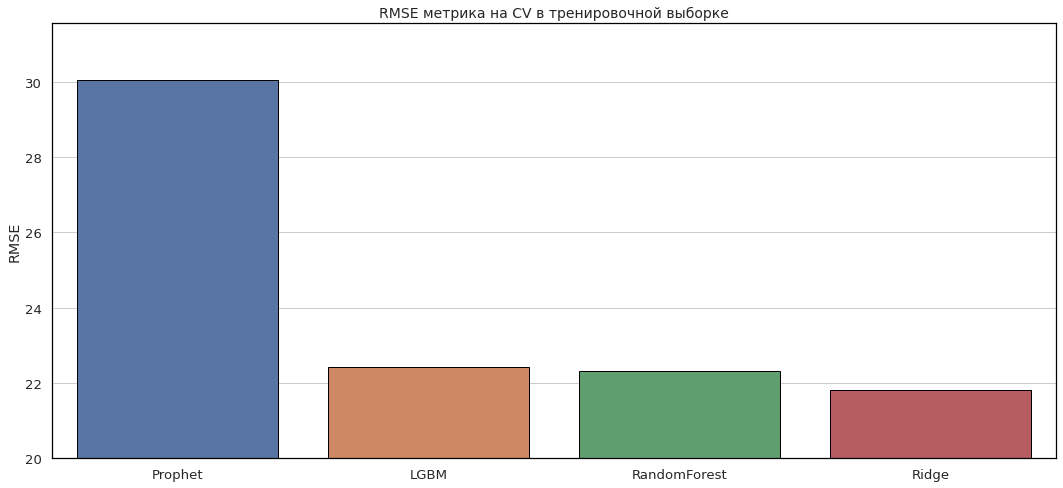

In [28]:
sns.set(font_scale=1.2)
sns.set_style('whitegrid', {'axes.edgecolor': 'black'})

fig = plt.figure(figsize=(18,8))
sns.barplot(data=comparison, 
                  x='model', 
                  y='CV_RMSE',
                  edgecolor='black')
plt.title('RMSE метрика на CV в тренировочной выборке', fontsize=14)
plt.xlabel('')
plt.ylabel('RMSE')

plt.ylim(bottom=20)
comparison

### Вывод

Получили следующие метрики на кросс-валидации с 5 фолдами
- **Ridge - 21.82**
- Random Forest - 22.31
- LGBM - 22.42
- Prophet - 30.05 - вероятно, из-за особенности модели на часовое предсказание не самый лучший вариант, тем более, с таким маленьким датасетом


- Лучшая модель Ridge со следующими гиперпараметрами
    - `alpha` - 0.1
    - `max_iter` - 3000
    - Преобразование входных данных и дополнительные признаки
        - MinMaxScaler
        - max_lag - 168 - максимальное колечство лагов, кратных 24 часам
        - max_lag_intraday - 3 - внутридневные лаги кратные 3 часам до 24 часов
        - rolling_mean_size - 12 - скользящее среднее с окном 12 часов

## Анализ лучшей модели

Оценим метрику RMSE лучшей модели

In [29]:
best_model = model_ridge.fit(train, train['num_orders'])
y_pred = best_model.predict(test)
print('RMSE - ', round(root_mean_squared_error(y_pred, test['num_orders']), 2))

RMSE -  34.51


Отлично, выполняются требования заказчика, посмотрим на реальные и предсказанные значения во времени

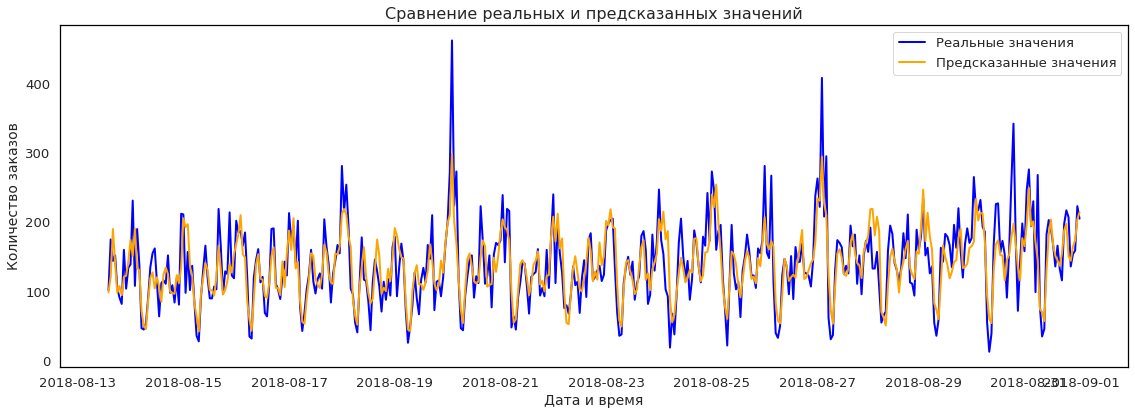

In [30]:
plt.figure(figsize=(16, 6))
plt.plot(test.index, test['num_orders'], label='Реальные значения', color='blue', linewidth=2)
plt.plot(test.index, y_pred, label='Предсказанные значения', color='orange', linewidth=2)

# Настройка графика
plt.title('Сравнение реальных и предсказанных значений', fontsize=16)
plt.xlabel('Дата и время', fontsize=14)
plt.ylabel('Количество заказов', fontsize=14)
plt.legend()
plt.grid(False)

# Показать график
plt.tight_layout()
plt.show()

- В целом предсказанные значения неплохо повторяют реальные данные и их зависимость от времени
- Есть проблема с выбросами в выходные, которых раньше не было, о чем мы говорили в исследовательском анализе, хотя в некоторой степени повторяет их тренд
- Небольшие проблемы во внутредневных колебаниях, но там количество заказов изменяется в пределах 20-40 шутк, что в целом не критично
- По больше части модель верно определяет основные моменты, когда реально следует направить больше машин в аэропорт, для более тонкой работы необходимо больше данных и другие модели, возможно LSTM

## Общий вывод

В результате данного исследования на основе исторических данных о заказах такси в аэропорту были созданы 4 модели с набором гиперпарамтеров - Ridge, Random Forest, LGBM и Prophet. Все модели на кросс-валидации показали метрики, удовлетворяющие требованию заказчика. Лучше моделью по RSME оказалась **Ridge** с метрикой **RMSE - 34.5** на тестовой выборке и **21.8** на тренировочной выборке

**Исходные данные**
- 26496 записей
- Период с 1 марта 2018 по 31 августа 2018 года
- Интервал 10 минут    
- Ресемплировали по 1 часу, стало 4416 записей
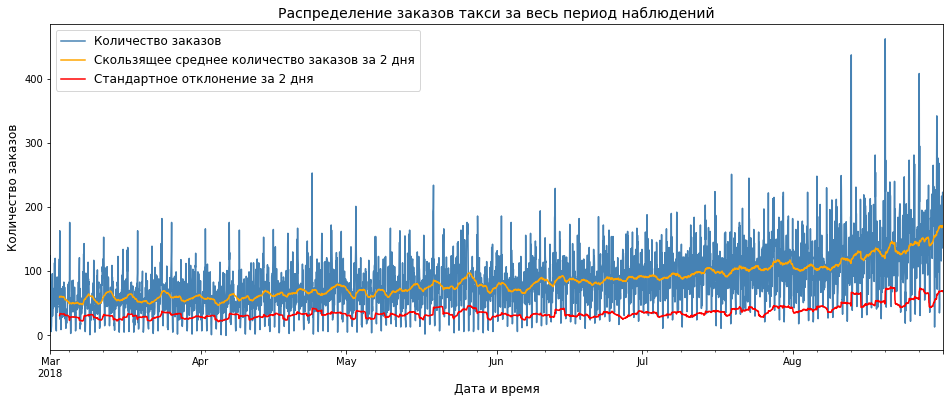

**Исследовательский анализ**

- Ряд стационарен (**p**=0.029)
- Тренд постепенно возрастает к концу периода наблюдений, к августу
- Сезонность - 1 день
- По остаткам есть выбросы в конце наблюдений, в августе, что связано с возвращаением отпусков
- Автокорреляция 
    - Локальные максимумы кратны 24 часам с r около 0.30
    - Так же хорошую автокорреляцию показывает значение через 1 и 2 часа на уровне около 0.60 и 0.45
    - Сдвиги без промежуточных взаимосвязей показывают сильную корреляцию с сдвигами
        1 - около 0.61
        22-24 - около 0.3
        48 и далеее кратные 24 - около 0.3
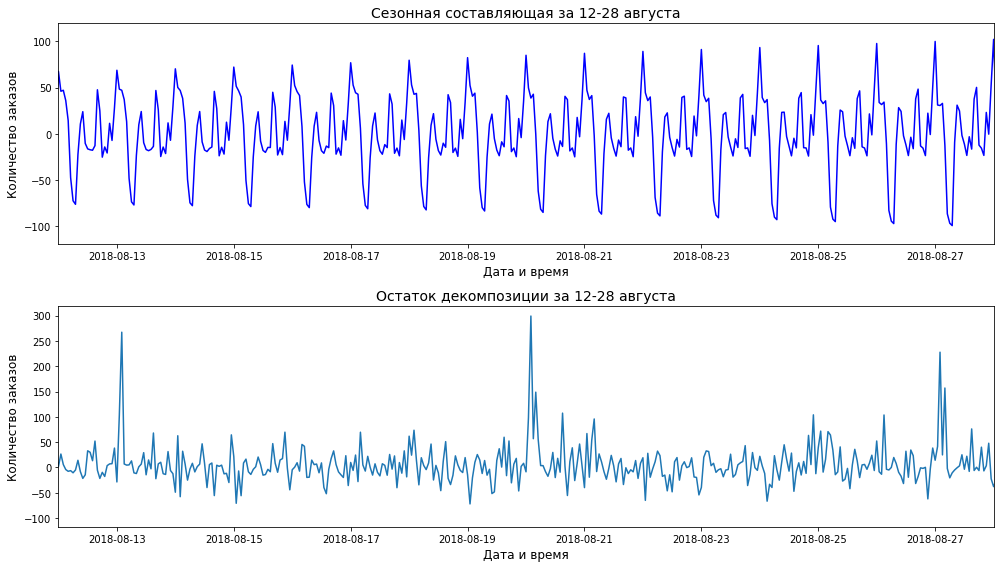

**Обучение моделей**
- Обучено 4 модели
    - Ridge
    - Random Forest
    - LGBM 
    - Prophet


- Подбор гиперпараметров осуществлялся с помощью HyperOpt и RandomizedSearchCV
- Кросс-валидация на 5 фолдах

**Анализ моделей**
- RMSE метрика
    - **Ridge - 21.82**
    - Random Forest - 22.31
    - LGBM - 22.42
    - Prophet - 30.05
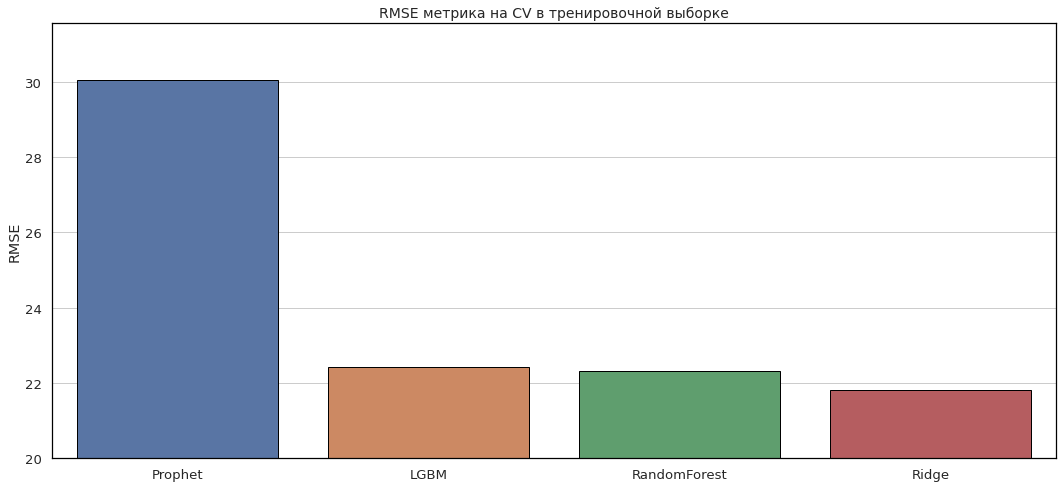

- **Лучшая модель Ridge со следующими гиперпараметрами**
    - `alpha` - 0.1
    - `max_iter` - 3000
    - Преобразование входных данных и дополнительные признаки
        - `MinMaxScaler`
        - `max_lag` - 168 - максимальное колечство лагов, кратных 24 часам
        - `max_lag_intraday` - 3 - внутридневные лаги кратные 3 часам до 24 часов
        - `rolling_mean_size` - 12 - скользящее среднее с окном 12 часов
    - **RMSE метрика на тестовой выборке - 34.5**
    - **RMSE метрика на тренировочной выборке - 21.8**
    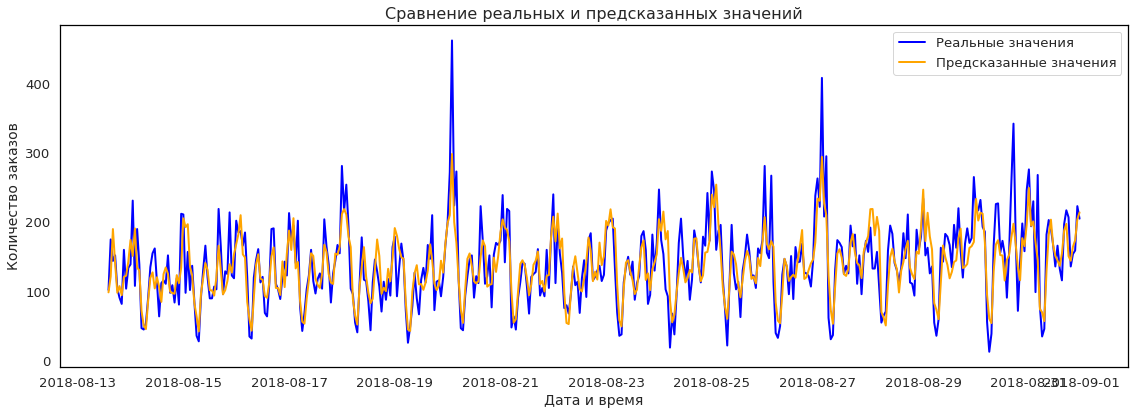

**Возможные улучшения модели**
- Поработать в дополнительными признаками сдвига и скользящей средней, возможно взять только хорошие по автокорреляции
- Увеличить выборку или уменшить масштаб обратно до 5 минут
- Попробовать LSTM, возможно Prophet на большей выборке

**Рекомендации заказчику**
- Модель неплохо предсказывает 3-часовые промежутки, когда необходимо увеличить или уменьшить количество машин в аэропорту
- Пиковые значения на выходных в августе модель угадывает по направлению, но не достает по силе, поэтому необходимо больше исторических данных, возможно за последние года, а пока держать в уме такие типично-сезонные дни
- При необходимости более точного предсказания промежуточных непиковых часов необхоима выборка меньше масштаба, чем часовая и большего размера, после переобучения модель должна справляться лучше, как альтернатива - попробовать другие варианты моделей, например LSTM